In [23]:
# Setup: Import all required libraries.
# - OpenCV: image processing
# - NumPy: numerical operations
# - Matplotlib: visualization
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4,4)

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

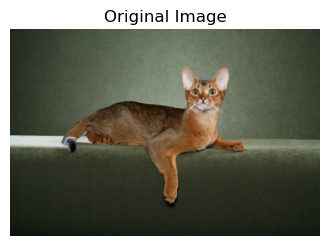

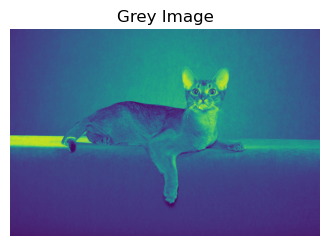

In [25]:
# ==========================================
# 1. Load One Example Image
# ==========================================
# We start with a single image to understand how segmentation works.
image_path = "./dataset/images/Abyssinian_1.jpg" # This is the image
annotation_path = "./dataset/masks/Abyssinian_1.png" # The corresponding annotation (mask), we will use it as ground truth
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.figure(1)
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')
plt.figure(2)
plt.title("Grey Image")
plt.imshow(gray)
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

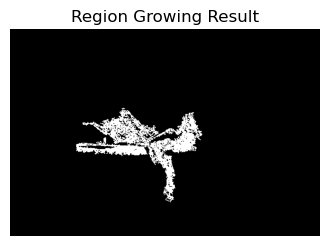

In [26]:
# ==========================================
# 2. Region Growing (Demo on Single Image)
# ==========================================
# Region growing starts from a seed pixel and expands to neighbors if they are similar in intensity.
# Key parameters:
# - seed: starting pixel
# - threshold: how similar pixels must be
# Simple implementation inline (for understanding)
from inspect import stack

from sklearn import neighbors


def region_growing_demo(image, seed, threshold=15):
    h, w = image.shape # get the height and width of the image
    segmented = np.zeros((h, w), dtype=np.uint8) # output segmented image, here we hold the reusltant image
    visited = np.zeros((h, w), dtype=bool) # this keeps tracks of which pixels have been visited to avoid infinite loops
    seed_value = image[seed] # we input a random pixel, and get its intensity value
    stack = [seed] # stack that will hold pixels to explore
    while stack:
        x, y = stack.pop() # get the last pixel from the stack
        if visited[x, y]:
            continue # if we have already visited this pixel, skip it
        visited[x, y] = True # mark this pixel as visited
        if abs(int(image[x, y]) - int(seed_value)) < threshold:
            segmented[x, y] = 255 #if the difference in intensity is less than the threshold, we consider it part of the region and set it to 255 (white) in the segmented image
            # 4-connected neighbors
            neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)] #if the neighboring pixels are within the image bounds, we add them to the stack to be explored next
            for nx, ny in neighbors:
                if 0 <= nx < h and 0 <= ny < w:
                    stack.append((nx, ny))

    return segmented
# Try different seeds and thresholds to observe behavior
h, w = gray.shape # get the height and width of the image
seed = (h//2, w//2) # let's start with the central pixel
region_result = region_growing_demo(gray, seed, threshold=15) #apply region growing with the specified seed and threshold
plt.title("Region Growing Result")
plt.imshow(region_result, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

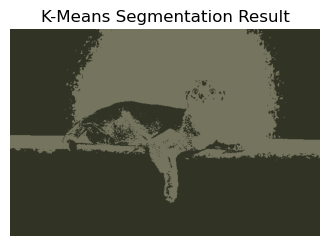

In [27]:
# ==========================================
# 2. K-Means Segmentation (Demo on Single Image)
# ==========================================
# K-Means clusters pixels into K groups based on similarity.
# We must specify the number of clusters (K).
# Here, we use color features only: [R, G, B]
# Prepare data
Z = image.reshape((-1,3))
Z = np.float32(Z)
# Define number of clusters
K = 2
# Apply K-Means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0) # termination criteria: either 10 iterations or accuracy of 1.0
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS) # apply k-means clustering to the pixel data
# Convert back to image
centers = np.uint8(centers) #center values are the mean color of each cluster, we convert them back to uint8 format
segmented_kmeans = centers[labels.flatten()] # we look up the cluster center for each pixel and create the segmented image by replacing each pixel's color with the color of its cluster center
segmented_kmeans = segmented_kmeans.reshape((image.shape))
plt.title("K-Means Segmentation Result")
plt.imshow(segmented_kmeans)
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

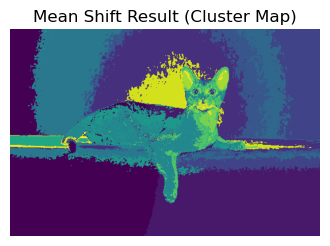

In [29]:
# ==========================================
# 3. Mean Shift (Demo on Single Image)
# ==========================================
# In image segmentation, the feature space typically includes:
# - Color (R, G, B)
# - Spatial position (x, y)
# Key parameters:
# - bandwidth: controls the size of the neighborhood (very important!)
# * small bandwidth → many small segments (over-segmentation)
# * large bandwidth → fewer large regions (under-segmentation)
from sklearn.cluster import MeanShift
h, w, _ = image.shape
# Build feature vectors: [R, G, B, x, y]
X = []
for i in range(h):
    for j in range(w):
        r, g, b = image[i, j]
        X.append([r, g, b, i/10, j/10]) # gives image color and spatial information, we divide x and y by 10 to scale down the spatial features so that they are on a similar scale as the color features
X = np.array(X)
# Apply Mean Shift clustering
ms = MeanShift(bandwidth=20, bin_seeding=True)
labels = ms.fit_predict(X)
segmented = labels.reshape((h, w))
plt.title("Mean Shift Result (Cluster Map)")
plt.imshow(segmented)
plt.axis('off')

In [30]:
# ==========================================
# Define reusable functions
# ==========================================
# Region grwoing method
def region_growing(image, seed, threshold=15):
    h, w = image.shape
    segmented = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=bool)
    seed_value = image[seed]
    stack = [seed]
    while stack:
        x, y = stack.pop()
        if visited[x, y]:
            continue
        visited[x, y] = True
        if abs(int(image[x, y]) - int(seed_value)) < threshold:
            segmented[x, y] = 1
            neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
            for nx, ny in neighbors:
                if 0 <= nx < h and 0 <= ny < w:
                    stack.append((nx, ny))
    return segmented
# K-Means method
def kmeans_segmentation(image, K=3):
    Z = image.reshape((-1,3))
    Z = np.float32(Z)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    segmented = centers[labels.flatten()]
    segmented = segmented.reshape((image.shape))
    return segmented

# Mean Shift method
def mean_shift_segmentation(image, spatial_radius=10, color_radius=20):
    h, w, c = image.shape
    X = []
    for i in range(h):
        for j in range(w):
            r, g, b = image[i, j]
            X.append([r, g, b, i/spatial_radius, j/spatial_radius])
    X = np.array(X)
    ms = MeanShift(bandwidth=color_radius, bin_seeding=True)
    labels = ms.fit_predict(X)
    segmented = labels.reshape((h, w))
    return segmented

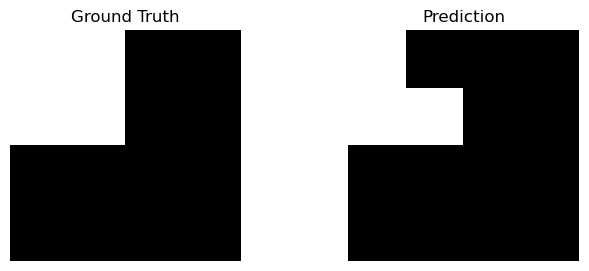

Example IoU: 0.750
Example Dice: 0.857


In [31]:
# ==========================================
# Evaluation metrics
# ==========================================
# Define IoU
def compute_iou(gt, pred):
    intersection = np.logical_and(gt, pred).sum() #sum all the pixels where both gt and pred are 1 (true positives)
    union = np.logical_or(gt, pred).sum() #sum all the pixels where either gt or pred is 1 (true positives + false positives + false negatives)
    return intersection / (union + 1e-6)
    # Define Dice
    
def compute_dice(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    return (2. * intersection) / (gt.sum() + pred.sum() + 1e-6)
# Let's see an example here: suppose we have the following prediction and the ground truth
gt_example = np.array([
[1, 1, 0, 0],
[1, 1, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]
])
pred_example = np.array([
[1, 0, 0, 0],
[1, 1, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]
])
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title("Ground Truth")
plt.imshow(gt_example, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Prediction")
plt.imshow(pred_example, cmap='gray')
plt.axis('off')
plt.show()
# Compute metrics for the example
iou_example = compute_iou(gt_example, pred_example)
dice_example = compute_dice(gt_example, pred_example)
print(f"Example IoU: {iou_example:.3f}")
print(f"Example Dice: {dice_example:.3f}")

In [33]:
# ==========================================
# Batch Processing
# ==========================================
# We now process a folder of images automatically.In [122…In [129…
# Folder structure:
# dataset/
# ├── images/
# ├── masks/
# The dataset labels:
# 1 = Foreground (pet)
# 2 = Background
# 3 = Not classified (ignore)
# We will convert GT masks to binary (1 = foreground, 0 = else) and
# ignore pixels labeled 3 when computing IoU and Dice.
import os
from tqdm import tqdm
# Create folder to save predictions
save_folder = "dataset/predictions"
os.makedirs(save_folder, exist_ok=True)

results = []

def process_and_save(image_folder, mask_folder, method='region'):
    results = []
    for filename in tqdm(os.listdir(image_folder)):
    # Image file is JPG
        img_path = os.path.join(image_folder, filename) #gives you full path to the image file
        # Corresponding mask file is PNG (replace extension)
        mask_name = os.path.splitext(filename)[0] + '.png' # we take the filename, remove the extension and add .png to get the corresponding mask filename
        mask_path = os.path.join(mask_folder, mask_name)
        image = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        # Load GT mask
        gt = cv2.imread(mask_path, 0) # single-channel, this is your ground truth mask
        # Convert GT to binary mask (foreground = 1)
        gt_binary = np.where(gt == 1, 1, 0) # we create a binary mask where pixels labeled 1 in the GT are set to 1 (foreground) and all other pixels are set to 0 (background)
        # Valid mask (exclude pixels labeled 3)
        valid_mask = gt != 3 #ignores pixels labeled 3 in the GT when computing metrics
        # Apply segmentation method
        if method == 'region':
            h, w = gray.shape
            center_seed = (h//2, w//2)
            pred_mask = region_growing(gray, seed=center_seed, threshold=15)
        elif method == 'mean_shift':
            pred_seg = mean_shift_segmentation(image_rgb)
            # Use center pixel cluster for foreground
            h, w, _ = image_rgb.shape
            pred_mask = (pred_seg == pred_seg[h//2, w//2]).astype(np.uint8)
        elif method == 'kmeans':
            pred_seg = kmeans_segmentation(image_rgb, K=3)
            # Use center pixel cluster for foreground
            h, w, _ = image_rgb.shape
            center_cluster = pred_seg[h//2, w//2, 0] # R channel
            pred_mask = (pred_seg[:,:,0] == center_cluster).astype(np.uint8)
        else:
            raise ValueError("Unknown method")
            #Save segmentation result as PNG
        save_path = os.path.join(save_folder, f"{os.path.splitext(filename)[0]}_{method}.png")
        cv2.imwrite(save_path, (pred_mask*255).astype(np.uint8))
        # Compute metrics using valid pixels only
        iou = compute_iou(gt_binary[valid_mask], pred_mask[valid_mask])
        dice = compute_dice(gt_binary[valid_mask], pred_mask[valid_mask])
        results.append((filename, iou, dice, save_path))
    return results
#Example usage
image_folder = "dataset/images"
mask_folder = "dataset/masks"
results = process_and_save(image_folder, mask_folder, method='mean_shift')
# Print summary
for name, iou, dice, save_path in results:
    print(f"{name}: IoU={iou:.3f}, Dice={dice:.3f}, Saved: {save_path}")

100%|██████████| 5/5 [02:42<00:00, 32.47s/it]

Abyssinian_1.jpg: IoU=0.454, Dice=0.624, Saved: dataset/predictions\Abyssinian_1_mean_shift.png
Abyssinian_2.jpg: IoU=0.002, Dice=0.004, Saved: dataset/predictions\Abyssinian_2_mean_shift.png
Abyssinian_3.jpg: IoU=0.369, Dice=0.540, Saved: dataset/predictions\Abyssinian_3_mean_shift.png
Abyssinian_4.jpg: IoU=0.142, Dice=0.248, Saved: dataset/predictions\Abyssinian_4_mean_shift.png
Abyssinian_5.jpg: IoU=0.389, Dice=0.560, Saved: dataset/predictions\Abyssinian_5_mean_shift.png


Top 2 Best Segmentation Results


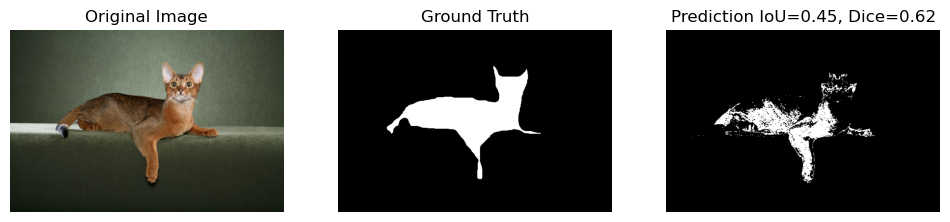

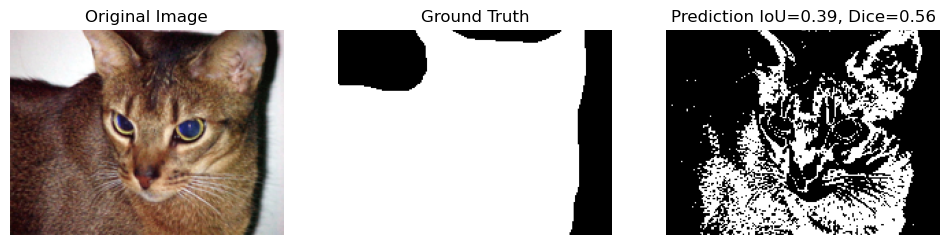

Top 2 Worst Segmentation Results


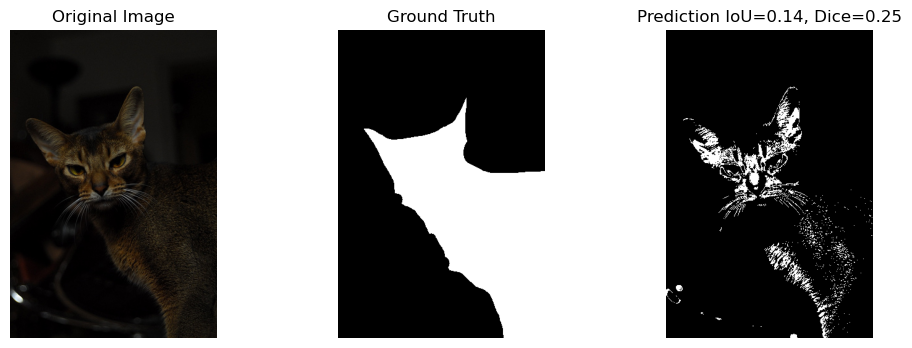

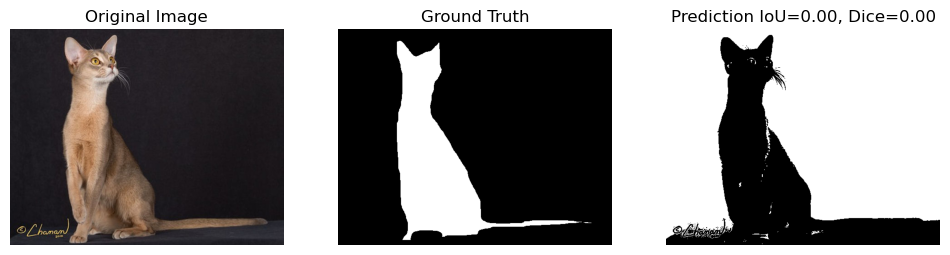

In [ ]:
# ==========================================
# Visualize Best and Worst Cases
# ==========================================
# Sort results by IoU (you can also sort by Dice if preferred)
sorted_results = sorted(results, key=lambda x: x[1], reverse=True) #sort by iou in descending order
best_cases = sorted_results[:2] #first two are the best cases
worst_cases = sorted_results[-2:] #last two are the worst cases
def visualize_cases(cases, title):
    print(f"{title}")
    for filename, iou, dice, save_path in cases:
        img_path = os.path.join(image_folder, filename)
        mask_name = os.path.splitext(filename)[0] + '.png'
        mask_path = os.path.join(mask_folder, mask_name)
        image = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        gt = cv2.imread(mask_path, 0)
        gt_binary = np.where(gt == 1, 1, 0)
        pred_mask = cv2.imread(save_path, 0) // 255
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.title("Original Image")
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(gt_binary, cmap='gray')
        plt.axis('off')
        plt.subplot(1,3,3)
        plt.title(f"Prediction IoU={iou:.2f}, Dice={dice:.2f}")
        plt.imshow(pred_mask, cmap='gray')
        plt.axis('off')
        plt.show()
# Visualize
visualize_cases(best_cases, "Top 2 Best Segmentation Results")
visualize_cases(worst_cases, "Top 2 Worst Segmentation Results")